In [1]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
        # quantization_config=BitsAndBytesConfig(
        #     load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16
        # ),
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

/cloud-dev/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
# to match Gemma Scope
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [3]:
from concurrent.futures import ThreadPoolExecutor
from transformers_sae.ops import find_latest_checkpoint, load_checkpoint

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer_finetuned/"

saes = {}

def load_layer_checkpoint(layer):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None:
        sae = load_checkpoint(checkpoint).sae
        sae.eval()
        sae.onload()
        print(f"Loaded checkpoint for layer {layer}")
        return layer, sae
    else:
        print(f"No checkpoint found for layer {layer}")
        return layer, None

# Load the latest checkpoints for each layer in parallel
with ThreadPoolExecutor() as executor:
    results = executor.map(load_layer_checkpoint, range(model.num_layers - 1, -1, -1))
    for layer, sae in results:
        if sae is not None:
            saes[layer] = sae


Loaded checkpoint for layer 0
Loaded checkpoint for layer 3
Loaded checkpoint for layer 6
Loaded checkpoint for layer 15
Loaded checkpoint for layer 17
Loaded checkpoint for layer 21
Loaded checkpoint for layer 9
Loaded checkpoint for layer 18
Loaded checkpoint for layer 22
Loaded checkpoint for layer 10
Loaded checkpoint for layer 20
Loaded checkpoint for layer 23
Loaded checkpoint for layer 2
Loaded checkpoint for layer 1
Loaded checkpoint for layer 19Loaded checkpoint for layer 24

Loaded checkpoint for layer 5
Loaded checkpoint for layer 13
Loaded checkpoint for layer 11
Loaded checkpoint for layer 16
Loaded checkpoint for layer 14
Loaded checkpoint for layer 25
Loaded checkpoint for layer 7
Loaded checkpoint for layer 4
Loaded checkpoint for layer 8
Loaded checkpoint for layer 12


In [4]:
import numpy as np

from transformers_sae.validation import run_validations

validations = {}
geom_kl = {}

for start_layer in range(0, model.num_layers):
    print(f"Running validations for replacement starting at {start_layer}")
    validations[start_layer] = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        1,# TRAINING_BATCH_SIZE,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=start_layer,
        eval_layers=[start_layer, model.num_layers],
    )
    geom_kl[start_layer] = np.exp(
        np.mean(
            np.log(np.clip(validations[start_layer].layer_results[model.num_layers].kl, min=1e-9))
        )
    ).item()
    print(geom_kl[start_layer])


Running validations for replacement starting at 0


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

2.347659111022949
Running validations for replacement starting at 1


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

1.9160586595535278
Running validations for replacement starting at 2


...

0.008576037362217903
Running validations for replacement starting at 24


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.006661226041615009
Running validations for replacement starting at 25


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.004874800331890583


In [5]:
from transformers_sae.ops import save_validations

save_validations(validations, "/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_finetuned/")

In [6]:
from transformers_sae.ops import load_validations
gemma_scope_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/gemma_scope/")
next_layer_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer/")
next_layer_finetuned_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_finetuned/")
gemma_scope_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in gemma_scope_validations.items()
}
next_layer_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_validations.items()
}
next_layer_finetuned_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_finetuned_validations.items()
}

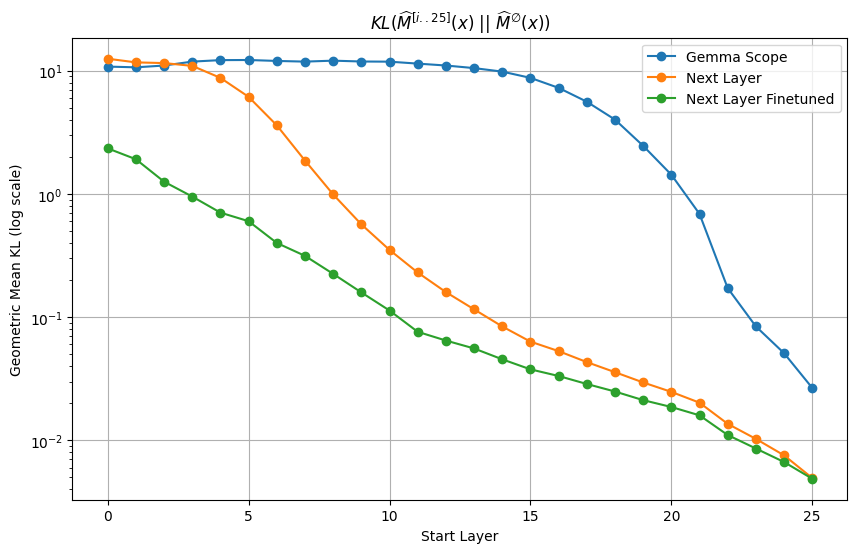

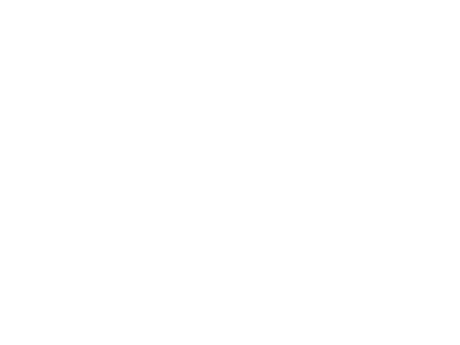

In [7]:
import matplotlib.pyplot as plt
from transformers_sae.ops import current_plot_to_svg

layers = sorted(gemma_scope_kl.keys())
plt.figure(figsize=(10, 6))
plt.plot(layers, [gemma_scope_kl[layer] for layer in layers], marker='o', label="Gemma Scope")
plt.plot(layers, [next_layer_kl[layer] for layer in layers], marker='o', label="Next Layer")
plt.plot(layers, [next_layer_finetuned_kl[layer] for layer in layers], marker='o', label="Next Layer Finetuned")
plt.xlabel('Start Layer')
plt.ylabel('Geometric Mean KL (log scale)')
plt.yscale("log")
plt.title('$KL(\\widehat{{M}}^{{[i..25]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$')
plt.grid(True)
plt.legend()
plt.show()

current_plot_to_svg("replacement_kl", ".plots")


In [ ]:
# import numpy as np

# from transformers_sae.validation import run_validations

# validations = run_validations(
#     model,
#     tokenizer,
#     saes,
#     validation_dataset,
#     TOKENIZER_BATCH_SIZE,
#     TRAINING_BATCH_SIZE,
#     NUM_VALIDATION_TOKENS,
#     cache_dir=VALIDATION_CACHE_DIR,
#     # start_layer=25
#     start_layer=min(saes.keys()),
# )
# print(
#     f"mean rre={ {k: np.mean(v.rre).item() for k, v in validations.layer_results.items() if v.rre is not None} }"
# )
# print(
#     f"mean l0={ {k: np.mean(v.l0).item() for k, v in validations.layer_results.items() if v.l0 is not None} }"
# )
# print(
#     f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validations.layer_results.items() if v.kl is not None} })"
# )
# print(
#     f"arith mean kl={ {k: np.mean(v.kl).item() for k, v in validations.layer_results.items() if v.kl is not None} }"
# )
# print(
#     f"live features={ {k: sum(v.live_features) / saes[25].config.d_sae for k, v in validations.layer_results.items() if v.live_features is not None} }"
# )

In [7]:
from transformers_sae.validation import generate_with_replacement

# no SAES
# Paris, is a city that is known for its rich history, culture, and architecture.
# It is also a city that is known for its fashion and style.
# Paris is a city that is always changing and evolving, and it is a city that is always on the cutting edge
# of fashion.

with torch.autocast(
    device_type="cuda" if model.device.type == "cuda" else "cpu",
    dtype=torch.bfloat16,
):
    generate_with_replacement(
        model,
        tokenizer,
        "The capital of France,",
        # {25: gemma_scope},
        # {},
        {layer: sae for layer, sae in saes.items() if layer > 0},
        # saes,
    )

 whosoever not quite confuse Arca


  PPS."</sDockStyle the same orrorric doubtnut
."</s<eos>


In [3]:
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

gemma_scope = {}

for layer in range(0, model.num_layers):
    gemma_scope[layer] = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )

In [4]:
import numpy as np

from transformers_sae.validation import run_validations

validations = {}
geom_kl = {}

for start_layer in range(0, model.num_layers):
    print(f"Running validations for replacement starting at {start_layer}")
    validations[start_layer] = run_validations(
        model,
        tokenizer,
        gemma_scope,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        1,# TRAINING_BATCH_SIZE,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=start_layer,
        eval_layers=[start_layer, model.num_layers],
    )
    geom_kl[start_layer] = np.exp(
        np.mean(
            np.log(np.clip(validations[start_layer].layer_results[model.num_layers].kl, min=1e-9))
        )
    ).item()
    print(geom_kl[start_layer])


Running validations for replacement starting at 0


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

10.830137252807617
Running validations for replacement starting at 1


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

10.6840181350708
Running validations for replacement starting at 2


...

0.08408143371343613
Running validations for replacement starting at 24


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.05097268149256706
Running validations for replacement starting at 25


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.026637695729732513


In [5]:
from transformers_sae.ops import save_validations

save_validations(validations, "/workspace/sae_checkpoints/validations/gemma_2_2b/gemma_scope/")

In [26]:
from transformers_sae.validation import generate_with_replacement

with torch.autocast(
    device_type="cuda" if model.device.type == "cuda" else "cpu",
    dtype=torch.bfloat16,
):
    generate_with_replacement(
        model,
        tokenizer,
        "The capital of France,",
        gemma_scope,
        # {},
        # {layer: sae for layer, sae in saes.items() if layer > 24},
    )

 Paris is one of the most beautiful and vibrant cities in the world. famous for its historic museums, museums XNUMX 1 

 1  1 1  1
  1
   1//​ 1
     1// </blockquote>

 1//
    // 
    
    //
    // 
     1////////////////////////////////////////


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from ipywidgets import interact, FloatSlider


def plot_log_skew_normal(xi=0.0, omega=1.0, alpha=0.0):
    """
    Plot the log skew-normal distribution.
    xi: location parameter
    omega: scale parameter (must be > 0)
    alpha: shape/skewness parameter
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Generate x values (positive only for log-skew-normal)
    x = np.logspace(-8, 2, 50000)

    # Log skew-normal PDF: transform through log
    # If Y ~ SkewNormal(xi, omega, alpha), then X = exp(Y) ~ LogSkewNormal
    log_x = np.log(x)

    # Skew-normal PDF for log(x)
    z = (log_x - xi) / omega
    pdf_skewnorm = (2 / omega) * stats.norm.pdf(z) * stats.norm.cdf(alpha * z)

    # Jacobian adjustment for log transformation: divide by x
    pdf = pdf_skewnorm / x

    ax.plot(x, pdf, "b-", linewidth=2)
    ax.fill_between(x, pdf, alpha=0.3)
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_title(
        f"Log Skew-Normal Distribution\nξ={xi:.2f}, ω={omega:.2f}, α={alpha:.2f}",
        fontsize=14,
    )
    ax.set_xlim(1e-10, 1e2)
    ax.set_ylim(0, max(pdf) * 1.1 if max(pdf) > 0 else 1)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    plot_log_skew_normal,
    xi=FloatSlider(
        value=0.0, min=-30.0, max=30.0, step=0.01, description="ξ (location)"
    ),
    omega=FloatSlider(value=1.0, min=0.1, max=30.0, step=0.01, description="ω (scale)"),
    alpha=FloatSlider(
        value=0.0, min=-100.0, max=100.0, step=0.01, description="α (shape)"
    ),
);


interactive(children=(FloatSlider(value=0.0, description='ξ (location)', max=30.0, min=-30.0, step=0.01), Floa…